# Case: Cross-sensor intercomparison — vegetation indices, FLMS vs. all sensors, Plot 103

**Reference:** Werfeli, Mihai et al. (2026), *"Uncertainty propagation and
intercomparison of multi-sensor measurements of vegetation stress in
sub-optimal conditions."*

This notebook compares **Piccolo Doppio FLMS** against all 9 other
sensor/panel combinations measured at Plot 103, for the five vegetation
indices (NDVI, EVI, OSAVI, MTCI, PRI), using the same normalised error as
the reflectance case:

$$E_N = \frac{V_x - V_y}{\sqrt{u_c(V_x)^2 + u_c(V_y)^2}}$$

For the equivalent comparison of the reflectance spectrum, see
[`case_intercomparison-Ex2_Reflectance_AllSensors.ipynb`](case_intercomparison-Ex2_Reflectance_AllSensors.ipynb) —
kept as a separate notebook, matching the two separate real scripts this
material is based on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

DATA_DIR = "../data/case-intercomparison-plot103-full"
FILE = f"{DATA_DIR}/Indexes-7_cos_16062026.xlsx"
wb = openpyxl.load_workbook(FILE, data_only=True, read_only=True)

## 1. E_N agreement — vegetation indices, FLMS vs. every other sensor

`Indexes103` stores one row per sensor for each index (already the
plot-level value, not per-point), at fixed row numbers — the same rows the
original MATLAB code reads.

In [2]:
ws2 = wb["Indexes103"]
row_map = {"FLMS": 8, "QEP": 16, "ASD_WP1": 20, "ASD_WP2": 21,
           "SVC_WP1": 26, "SVC_WP2": 27, "ALTUM_GP": 31, "ALTUM_WP2": 32,
           "REMX_GP": 37, "REMX_WP2": 38}
# each index occupies 7 columns: point, value, u_r, u_s, u_homogeneity, u_c, U_k2
index_start = {"PRI": 1, "NDVI": 7, "NIRv": 13, "EVI": 19, "MTCI": 25, "OSAVI": 31}

def get_index_val_uc(sensor, idx_name):
    r = row_map[sensor]
    start = index_start[idx_name]
    val = ws2.cell(row=r, column=start + 1).value
    uc = ws2.cell(row=r, column=start + 5).value
    return val, uc

index_results = {}
for idx_name in ["NDVI", "EVI", "OSAVI", "MTCI", "PRI"]:
    val_f, uc_f = get_index_val_uc("FLMS", idx_name)
    if val_f is None:
        continue
    print(f"\n{idx_name} (FLMS = {val_f:.4f} +/- {uc_f:.4f}):")
    for name in row_map:
        if name == "FLMS":
            continue
        val_y, uc_y = get_index_val_uc(name, idx_name)
        if val_y is None or uc_f is None or uc_y is None:
            print(f"  vs {name:10s}: no data")
            continue
        En = (val_f - val_y) / np.sqrt(uc_f**2 + uc_y**2)
        index_results[(idx_name, name)] = En
        print(f"  vs {name:10s}: {idx_name}={val_y:+.4f}  En={En:+.3f}  |En|<=1: {'yes' if abs(En) <= 1 else 'no'}")


NDVI (FLMS = 0.9361 +/- 0.0031):
  vs QEP       : NDVI=+0.9391  En=-0.840  |En|<=1: yes
  vs ASD_WP1   : NDVI=+0.9346  En=+0.154  |En|<=1: yes
  vs ASD_WP2   : NDVI=+0.9348  En=+0.127  |En|<=1: yes
  vs SVC_WP1   : NDVI=+0.9205  En=+1.165  |En|<=1: no
  vs SVC_WP2   : NDVI=+0.9208  En=+1.422  |En|<=1: no
  vs ALTUM_GP  : NDVI=+0.8865  En=+6.511  |En|<=1: no
  vs ALTUM_WP2 : NDVI=+0.8673  En=+7.985  |En|<=1: no
  vs REMX_GP   : NDVI=+0.8512  En=+14.037  |En|<=1: no
  vs REMX_WP2  : NDVI=+0.8439  En=+14.753  |En|<=1: no

EVI (FLMS = 0.7263 +/- 0.0777):
  vs QEP       : no data
  vs ASD_WP1   : EVI=+0.7315  En=-0.059  |En|<=1: yes
  vs ASD_WP2   : EVI=+0.7668  En=-0.446  |En|<=1: yes
  vs SVC_WP1   : EVI=+0.6685  En=+0.636  |En|<=1: yes


  vs SVC_WP2   : EVI=+0.6407  En=+1.011  |En|<=1: no
  vs ALTUM_GP  : EVI=+0.7512  En=-0.318  |En|<=1: yes
  vs ALTUM_WP2 : EVI=+0.6126  En=+1.456  |En|<=1: no
  vs REMX_GP   : EVI=+0.7001  En=+0.336  |En|<=1: yes
  vs REMX_WP2  : EVI=+0.6121  En=+1.468  |En|<=1: no

OSAVI (FLMS = 0.7926 +/- 0.0327):
  vs QEP       : OSAVI=+0.7857  En=+0.193  |En|<=1: yes
  vs ASD_WP1   : OSAVI=+0.7924  En=+0.007  |En|<=1: yes
  vs ASD_WP2   : OSAVI=+0.8067  En=-0.356  |En|<=1: yes
  vs SVC_WP1   : OSAVI=+0.7596  En=+0.793  |En|<=1: yes
  vs SVC_WP2   : OSAVI=+0.7471  En=+1.194  |En|<=1: no
  vs ALTUM_GP  : OSAVI=+0.7765  En=+0.483  |En|<=1: yes


  vs ALTUM_WP2 : OSAVI=+0.7130  En=+2.382  |En|<=1: no
  vs REMX_GP   : OSAVI=+0.7462  En=+1.402  |En|<=1: no
  vs REMX_WP2  : OSAVI=+0.7058  En=+2.622  |En|<=1: no

MTCI (FLMS = 5.3359 +/- 0.1587):
  vs QEP       : MTCI=+5.0638  En=+1.376  |En|<=1: no
  vs ASD_WP1   : MTCI=+4.9845  En=+0.339  |En|<=1: yes
  vs ASD_WP2   : MTCI=+4.9664  En=+0.304  |En|<=1: yes
  vs SVC_WP1   : MTCI=+4.3572  En=+0.837  |En|<=1: yes
  vs SVC_WP2   : MTCI=+4.3548  En=+1.124  |En|<=1: no
  vs ALTUM_GP  : no data
  vs ALTUM_WP2 : no data
  vs REMX_GP   : no data
  vs REMX_WP2  : no data

PRI (FLMS = 0.0117 +/- 0.0072):
  vs QEP       : no data


  vs ASD_WP1   : PRI=-0.0005  En=+0.144  |En|<=1: yes
  vs ASD_WP2   : PRI=+0.0009  En=+0.111  |En|<=1: yes
  vs SVC_WP1   : PRI=-0.0153  En=+0.277  |En|<=1: yes
  vs SVC_WP2   : PRI=-0.0150  En=+0.339  |En|<=1: yes
  vs ALTUM_GP  : no data
  vs ALTUM_WP2 : no data
  vs REMX_GP   : PRI=-0.0543  En=+5.761  |En|<=1: no
  vs REMX_WP2  : PRI=-0.0064  En=+2.408  |En|<=1: no


## 2. Summary table, all indices vs. all sensors

In [3]:
idx_names = ["NDVI", "EVI", "OSAVI", "MTCI", "PRI"]
sensor_names = [n for n in row_map if n != "FLMS"]
table = pd.DataFrame(index=idx_names, columns=sensor_names, dtype=float)
for (idx_name, name), En in index_results.items():
    table.loc[idx_name, name] = En

table.style.format("{:+.2f}", na_rep="—").background_gradient(cmap="RdYlGn_r", vmin=-3, vmax=3, axis=None)

,QEP,ASD_WP1,ASD_WP2,SVC_WP1,SVC_WP2,ALTUM_GP,ALTUM_WP2,REMX_GP,REMX_WP2
NDVI,-0.84,+0.15,+0.13,+1.16,+1.42,+6.51,+7.98,+14.04,+14.75
EVI,—,-0.06,-0.45,+0.64,+1.01,-0.32,+1.46,+0.34,+1.47
OSAVI,+0.19,+0.01,-0.36,+0.79,+1.19,+0.48,+2.38,+1.40,+2.62
MTCI,+1.38,+0.34,+0.30,+0.84,+1.12,—,—,—,—
PRI,—,+0.14,+0.11,+0.28,+0.34,—,—,+5.76,+2.41


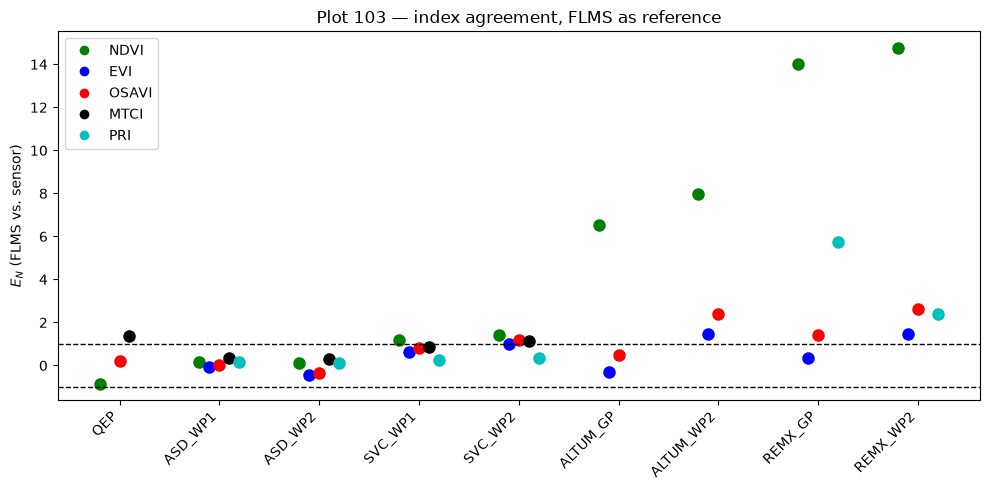

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
index_colors = {'NDVI': 'g', 'EVI': 'b', 'OSAVI': 'r', 'MTCI': 'k', 'PRI': 'c'}
offsets = {'NDVI': -0.2, 'EVI': -0.1, 'OSAVI': 0.0, 'MTCI': 0.1, 'PRI': 0.2}
for x, sensor in enumerate(sensor_names):
    for idx_name, color in index_colors.items():
        val = table.loc[idx_name, sensor]
        if pd.notna(val):
            ax.plot(x + offsets[idx_name], val, 'o', color=color, markersize=8)
ax.axhline(1, color='k', linestyle='--', linewidth=1)
ax.axhline(-1, color='k', linestyle='--', linewidth=1)
ax.set_xticks(range(len(sensor_names))); ax.set_xticklabels(sensor_names, rotation=45, ha='right')
ax.set_ylabel('$E_N$ (FLMS vs. sensor)')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=n)
           for n, c in index_colors.items()]
ax.legend(handles=handles)
ax.set_title('Plot 103 — index agreement, FLMS as reference')
plt.tight_layout(); plt.show()

---

**Code:** L. Mihai (laura.mihai@inflpr.ro) and Mike Werfeli (mike.werfeli@geo.uzh.ch)  
**Training material:** L. Mihai (laura.mihai@inflpr.ro)